# Gravity-darkened stars: `GravityDarkenedStar`

A star spinning close to its break-up rate is flattened at the poles and darkened at the equator, because the surface gravity, and with it the emergent flux, falls towards the equator. Long-baseline interferometers resolve exactly this: an oblate disk whose brighter pole leans in a particular direction on the sky. `drpangloss.models.GravityDarkenedStar` models it with the Espinosa Lara and Rieutord (2011, ELR11) Roche shape and gravity darkening, which has no free gravity-darkening exponent. The model is Shashank Dholakia's port of ELR11 into JAX, from his `jax-interferometry` code, brought into drpangloss with his `ELR_Model` as its grey mode and extended with a chromatic mode, in which every patch of the surface radiates as a black body at its own temperature.

This notebook builds such a star, compares it with a uniform disk of the same size, shows how the chromatic mode changes the picture with wavelength, and then simulates VLTI-like multi-channel data from a chromatic star and fits the rotation rate, inclination, pole position angle and size back from a perturbed start. You should come away knowing how to construct the model, what its parameters mean, and how to fit it with the same `fit` call as any other drpangloss model.

## Building a star

We set up the imports and then build a star with an equatorial angular diameter of 4 mas, large enough that VLTI resolves it, rotating at 90 percent of its critical rate, seen at an inclination of 50 degrees (0 is pole-on and 90 is equator-on), with its rotation pole pointing 30 degrees East of North. With no temperature given the model is the grey one, in which the brightness depends only on the local gravity and not on wavelength. `plot_surface` draws the visible surface mesh coloured by its local flux, with East to the left and North up, so the bright pole should appear towards the upper left and the dark, gravity-darkened equatorial belt across the middle.

/Users/benpope/code/drpangloss/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


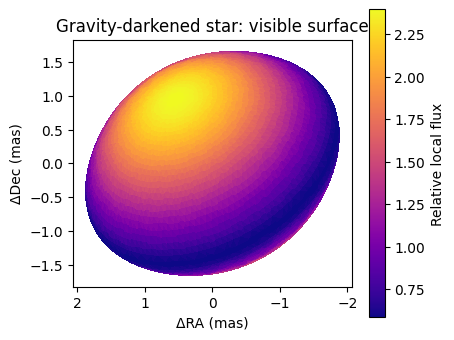

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist
from tqdm.auto import tqdm

from drpangloss.coverage import vlti_oidata
from drpangloss.fitting import fit
from drpangloss.models import GravityDarkenedStar, UniformDisk
from drpangloss.plotting import plot_data_model_correlation, plot_model

star = GravityDarkenedStar(4.0, omega=0.9, inc=50.0, pa=30.0, n_lat=64)
fig, ax = plt.subplots(figsize=(4.5, 4))
star.plot_surface(ax=ax)
ax.set_title("Gravity-darkened star: visible surface")
plt.show()

## Oblateness and the bright pole in the image

The mesh above is what the model sums over, but an interferometrist cares about the rendered image, so we render the star on a pixel grid with the common `plot_model` helper and set it next to a `UniformDisk` of the same equatorial diameter. Two things should stand out. The star is squashed along its rotation axis, so its projected outline is an ellipse with the short axis along the pole direction rather than a circle, and its brightness is concentrated towards the pole instead of being flat. These two effects are what make the visibilities depend on the baseline orientation, and so what a fit can use to recover `inc` and `pa`.

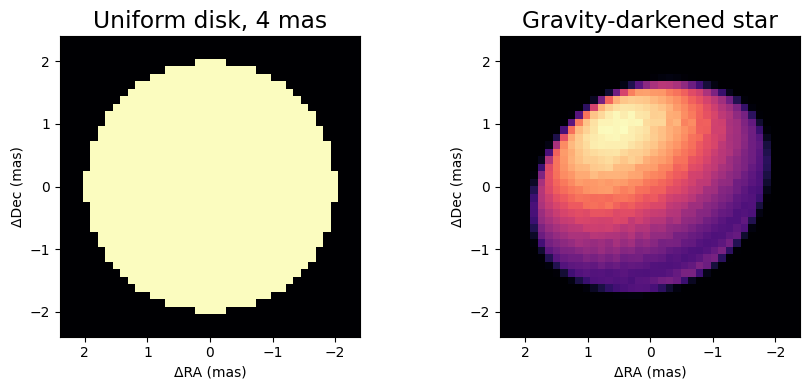

In [2]:
fov = 4.8
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_model(
    UniformDisk(diam=4.0),
    fov_mas=fov,
    npix=40,
    ax=axes[0],
    title="Uniform disk, 4 mas",
)
plot_model(
    star, fov_mas=fov, npix=40, ax=axes[1], title="Gravity-darkened star"
)
plt.tight_layout()
plt.show()

## The chromatic mode

In the grey mode the star looks the same at every wavelength. Setting `t_pole`, the effective temperature of the pole in kelvin, switches on the chromatic mode: each patch of the surface takes a temperature from the ELR11 gravity darkening and radiates the Planck function at that temperature, so at short wavelengths, where the Planck function is steepest, the hot pole outshines the cool equator by far more than at long wavelengths. The reference wavelength `wavel0` sets the wavelength at which `render` draws the star. We draw the same 9000 K star at 0.6 and at 3.0 microns, each panel on its own colour scale, to show the contrast between the pole and the equator becoming stronger at the shorter wavelength. These wavelengths are chosen far apart for visibility; the data we fit below span the narrower range from 1.6 to 2.4 microns. The mesh is refined to 64 latitude rings and the image drawn on a coarse grid, because `render` places each surface triangle on the nearest pixels and so looks speckled when the pixels are smaller than the triangles.

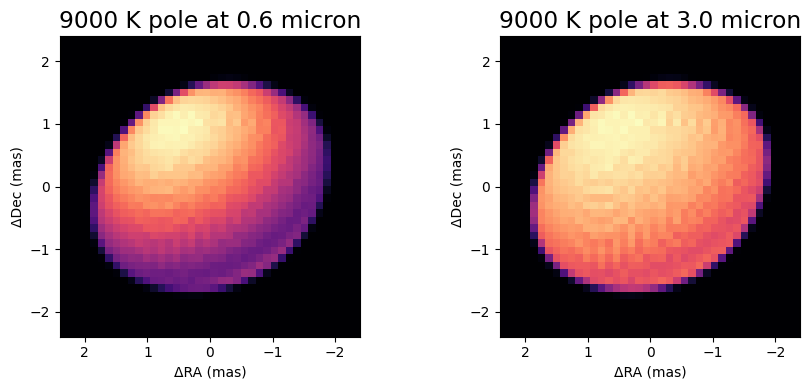

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, wavel0 in zip(axes, (0.6e-6, 3.0e-6)):
    hot = GravityDarkenedStar(
        4.0,
        omega=0.9,
        inc=50.0,
        pa=30.0,
        t_pole=9000.0,
        wavel0=wavel0,
        n_lat=64,
    )
    plot_model(
        hot,
        fov_mas=fov,
        npix=40,
        ax=ax,
        title=f"9000 K pole at {wavel0 * 1e6:.1f} micron",
    )
plt.tight_layout()
plt.show()

## Simulating and fitting multi-channel data

Now for a fit. `vlti_oidata` makes an empty dataset with VLTI-like uv coverage, here three snapshots of the four unit telescopes in six channels from 1.6 to 2.4 microns, with small errors on V² and the closure phases. A star of 4 mas is well resolved by baselines of up to 130 m at these wavelengths, which have a resolution of about 3 mas, and the longest baselines in the shortest channels reach the first null of the visibility. We fill the dataset with the observables of a chromatic star with the same truth as before, plus seeded Gaussian noise, using `with_model`. We then call `fit`, exactly as for any other drpangloss model, with a Uniform prior on each of the four parameters we want and a deliberately wrong starting star, and it returns the maximum a posteriori model. A coarser mesh (`n_lat=16`) keeps the visibilities cheap, and the temperature and reference wavelength are held fixed. The printed table compares the truth with the fit.

In [4]:
truth = GravityDarkenedStar(
    4.0, omega=0.9, inc=50.0, pa=30.0, t_pole=9000.0, n_lat=16
)
template = vlti_oidata(
    wavelengths_m=np.linspace(1.6e-6, 2.4e-6, 6),
    hour_angles_h=(-2.5, 0.0, 2.5),
    sigma_v2=0.003,
    sigma_cp_deg=0.3,
)
data = template.with_model(truth, key=jax.random.PRNGKey(1))
priors = {
    "diam_eq": dist.Uniform(1.0, 8.0),
    "omega": dist.Uniform(0.0, 0.99),
    "inc": dist.Uniform(0.0, 90.0),
    "pa": dist.Uniform(-90.0, 150.0),
}
start = GravityDarkenedStar(
    3.3, omega=0.6, inc=35.0, pa=0.0, t_pole=9000.0, n_lat=16
)
result = fit(start, priors, data)
print(f"{'':>9}{'truth':>8}{'start':>8}{'fit':>8}")
for name in tqdm(priors, desc="parameters", leave=False):
    print(
        f"{name:>9}{float(getattr(truth, name)):8.2f}{float(getattr(start, name)):8.2f}{float(result.values[name]):8.2f}"
    )
print(
    f"chi2 per data point: {result.info['chi2_red']:.2f} ({result.info['ndata'][0]} points)"
)

            truth   start     fit


  diam_eq    4.00    3.30    3.99
    omega    0.90    0.60    0.90
      inc   50.00   35.00   50.10
       pa   30.00    0.00   29.90
chi2 per data point: 0.97 (162 points)


## Checking the fit against the data

A chi-squared near one says the fit is statistically acceptable, but it is worth seeing where the model and data agree across the whole dynamic range. `plot_data_model_correlation` plots the model against the observed values, with the data errors as horizontal bars and a one-to-one line, for the squared visibilities on the left and the closure phases on the right. It expects a model summary with a mean and a spread; the fit is a single point estimate, so we pass its predictions with zero spread. Points on the line are well fitted, and the scatter about it should be of the size of the error bars. Here the closure phases carry real signal, tens of degrees on the longer triangles, because the hot visible pole makes the image asymmetric about its centre once the star is resolved; this is what lets the phases fix the position angle of the pole over the full 360 degrees and helps to separate the inclination from the rotation rate, which on their own both just squash the visibility.

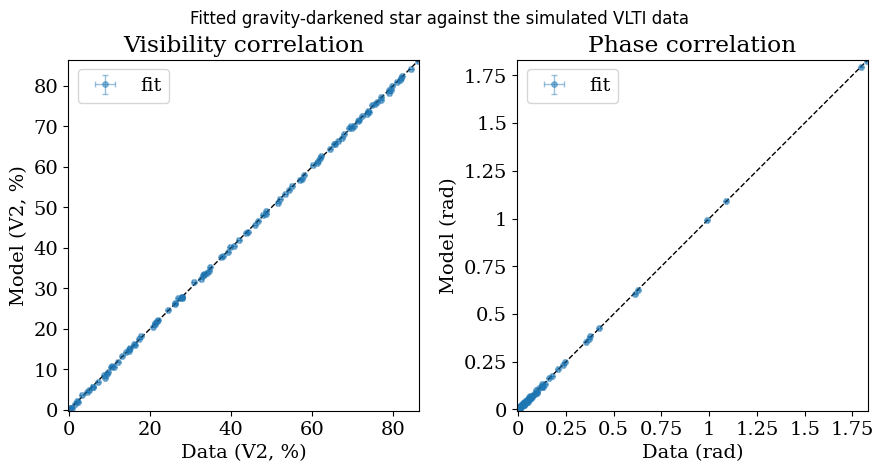

In [5]:
n_vis = data.vis.size
prediction = data.model(result.model)
summary = {
    "fit": {
        "vis_mean": prediction[:n_vis],
        "vis_std": 0 * prediction[:n_vis],
        "phi_mean": prediction[n_vis:],
        "phi_std": 0 * prediction[n_vis:],
    }
}
fig, (ax1, ax2) = plot_data_model_correlation(data, summary, figsize=(9, 4.5))
fig.suptitle(
    "Fitted gravity-darkened star against the simulated VLTI data", y=1.03
)
plt.show()

## Summary

`GravityDarkenedStar` gives drpangloss a physically motivated rapid rotator, with Dholakia's grey ELR11 model as the default and a chromatic mode, switched on by `t_pole`, in which the pole-to-equator contrast changes with wavelength. It renders, evaluates visibilities and fits like every other component, and so can also be placed in a `System` with a companion. Once the star is resolved, the squared visibilities constrain its size and flattening and the closure phases, which come from the asymmetry that the bright pole gives an inclined star, constrain its orientation and help to break the degeneracy between inclination and rotation rate. A star of about a milliarcsecond would be barely resolved by the VLTI in the H and K bands, its closure phases would be near zero, and those parameters would be much more weakly constrained.

For a fuller application, simulating CHARA-like data on a rapid rotator and retrieving its size, spin and orientation, see the notebook [`mwe_elr_chara`](https://github.com/benjaminpope/drpangloss/blob/main/notebooks/mwe/mwe_elr_chara.ipynb).